# CropIQ Phase 1 - Data Exploration
Reproducible exploration notebook. Every transformation performed here mirrors the scripts in `src/data/` - this notebook is for investigation and visualization, `src/data/*.py` is the source of truth for the pipeline.

## 1. Imports

In [1]:

import sys
sys.path.insert(0, str((__import__('pathlib').Path.cwd().parent / 'src' / 'data')))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from utils import load_dataset1, load_dataset2, parse_field_dates, iqr_outlier_mask

pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid')


## 2. Configuration

In [2]:

import os
os.chdir('..')  # repo root, so relative paths in utils.py resolve
FIGSIZE = (8, 5)


## 3. Load Raw Data

In [3]:

df1 = load_dataset1()
df2 = load_dataset2()
print('Dataset 1 (primary):', df1.shape)
print('Dataset 2 (secondary/contextual):', df2.shape)
df1.head()


Dataset 1 (primary): (1625, 13)
Dataset 2 (secondary/contextual): (50765, 20)


,field_id,date_of_image,latitude,longitude,NDVI,GNDVI,NDWI,SAVI,soil_moisture,temperature,rainfall,crop_type,yield
0,Field_1,01-01-2023,22.625231,88.497925,0.060190,0.084801,-0.084801,0.090280,46.119353,9.884229,1.662354,Rice,40.218031
1,Field_1,16-01-2023,22.625231,88.497925,0.213957,0.222009,-0.222009,0.320896,37.542525,13.967073,8.446302,Rice,30.870338
2,Field_1,31-01-2023,22.625231,88.497925,0.403306,0.431204,-0.431204,0.604837,24.926279,13.590147,3.862833,Rice,45.330050
3,Field_1,15-02-2023,22.625231,88.497925,0.418187,0.444132,-0.444132,0.627144,24.114157,12.343355,16.623542,Rice,49.711781
4,Field_1,03-02-2023,22.625231,88.497925,0.375138,0.387985,-0.387985,0.562591,27.420927,11.007707,9.496210,Rice,34.542646


## 4. Dataset Overview

In [4]:

df1.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1625 entries, 0 to 1624
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   field_id       1625 non-null   object 
 1   date_of_image  1625 non-null   object 
 2   latitude       1625 non-null   float64
 3   longitude      1625 non-null   float64
 4   NDVI           1625 non-null   float64
 5   GNDVI          1625 non-null   float64
 6   NDWI           1625 non-null   float64
 7   SAVI           1625 non-null   float64
 8   soil_moisture  1625 non-null   float64
 9   temperature    1625 non-null   float64
 10  rainfall       1625 non-null   float64
 11  crop_type      1625 non-null   object 
 12  yield          1625 non-null   float64
dtypes: float64(10), object(3)
memory usage: 165.2+ KB


In [5]:

df1.describe()


,latitude,longitude,NDVI,GNDVI,NDWI,SAVI,soil_moisture,temperature,rainfall,yield
count,1625.000000,1625.000000,1625.000000,1625.000000,1625.000000,1625.000000,1625.000000,1625.000000,1625.000000,1625.000000
mean,20.951964,78.046333,0.361759,0.374684,-0.374684,0.542582,28.230468,19.909141,9.561971,40.493210
std,6.798000,3.988114,0.218722,0.230745,0.230745,0.327977,13.855961,9.830494,5.112400,8.174425
min,9.801727,73.083890,-1.000000,-1.000000,-0.746486,-1.495781,4.433631,-4.790525,0.243661,26.853751
25%,15.120044,75.941381,0.237236,0.302930,-0.517085,0.355865,19.535173,12.588193,6.270283,33.196828
50%,22.343940,77.319258,0.361325,0.412269,-0.412269,0.541909,26.237796,19.982109,8.008841,40.750098
75%,26.706542,79.489981,0.504559,0.517085,-0.302930,0.756669,33.295736,26.181258,13.094685,46.102069
max,34.383462,93.341378,0.835025,0.746486,1.000000,1.252286,102.128741,44.979197,93.367483,89.293417


## 5. Schema Inspection

In [6]:

for c in df1.columns:
    print(f'{c:20s} {str(df1[c].dtype):10s} unique={df1[c].nunique()}')


field_id             object     unique=90
date_of_image        object     unique=25
latitude             float64    unique=90
longitude            float64    unique=90
NDVI                 float64    unique=1588
GNDVI                float64    unique=1588
NDWI                 float64    unique=1588
SAVI                 float64    unique=1588
soil_moisture        float64    unique=1588
temperature          float64    unique=1625
rainfall             float64    unique=1446
crop_type            object     unique=30
yield                float64    unique=1198


## 6. Missing Value Analysis
Dataset 1 has zero missing values in every column (confirmed below). The chart is still produced as required by the Phase 1 spec, and will simply show all-zero bars — this is the correct and honest result, not an error.

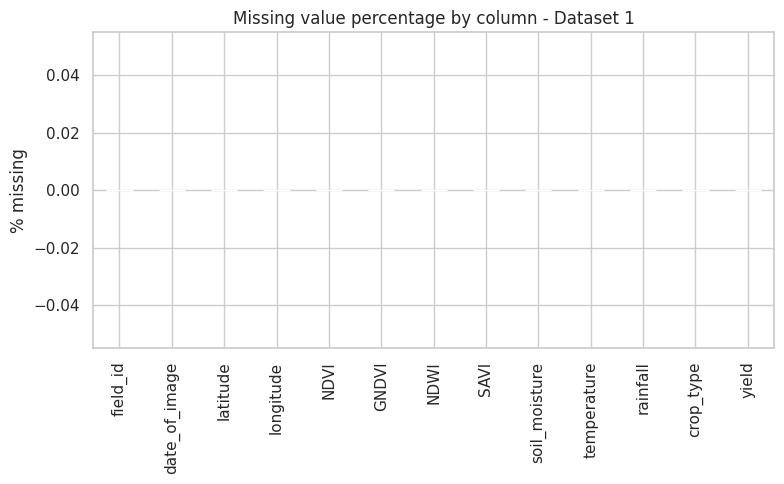

field_id         0.0
date_of_image    0.0
latitude         0.0
longitude        0.0
NDVI             0.0
GNDVI            0.0
NDWI             0.0
SAVI             0.0
soil_moisture    0.0
temperature      0.0
rainfall         0.0
crop_type        0.0
yield            0.0
dtype: float64


In [7]:

missing_pct = df1.isna().mean().sort_values(ascending=False) * 100
fig, ax = plt.subplots(figsize=FIGSIZE)
missing_pct.plot(kind='bar', ax=ax, color='#c0392b')
ax.set_ylabel('% missing')
ax.set_title('Missing value percentage by column - Dataset 1')
plt.tight_layout()
plt.savefig('reports/fig_missing_values.png', dpi=110)
plt.show()
print(missing_pct)


## 7. Duplicate Analysis

In [8]:

print('Exact duplicate rows:', df1.duplicated().sum())
print('field_id + date_of_image duplicate rows:', df1.duplicated(subset=['field_id','date_of_image']).sum())


Exact duplicate rows: 0
field_id + date_of_image duplicate rows: 0


## 8. Target Analysis

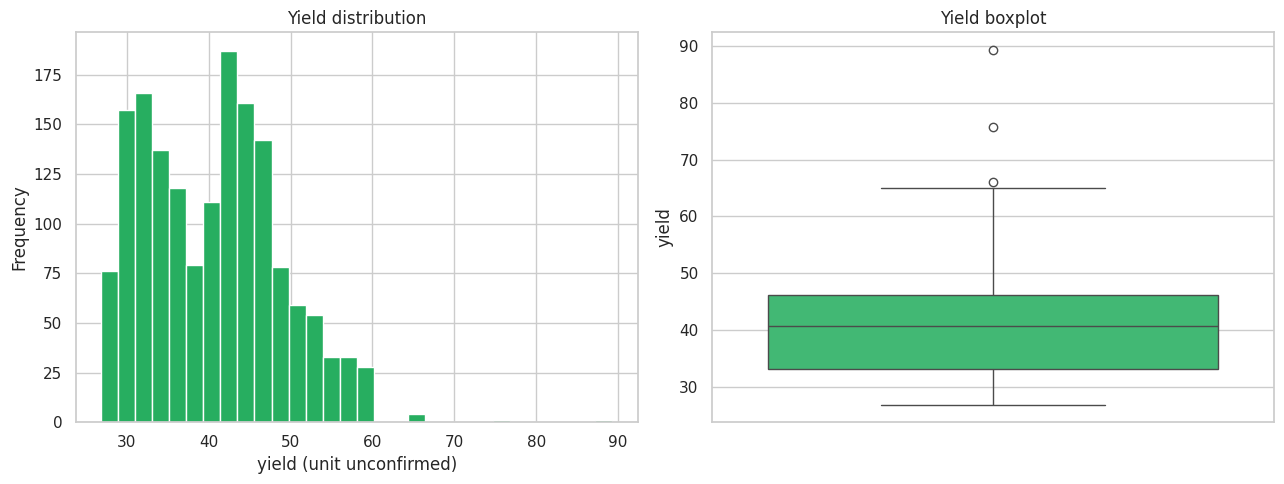

count    1625.000000
mean       40.493210
std         8.174425
min        26.853751
1%         27.849447
5%         29.015405
25%        33.196828
50%        40.750098
75%        46.102069
95%        54.698608
99%        58.535335
max        89.293417
Name: yield, dtype: float64

In [9]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
df1['yield'].plot(kind='hist', bins=30, ax=axes[0], color='#27ae60')
axes[0].set_title('Yield distribution')
axes[0].set_xlabel('yield (unit unconfirmed)')
sns.boxplot(y=df1['yield'], ax=axes[1], color='#2ecc71')
axes[1].set_title('Yield boxplot')
plt.tight_layout()
plt.savefig('reports/fig_target_distribution.png', dpi=110)
plt.show()
df1['yield'].describe(percentiles=[.01,.05,.25,.5,.75,.95,.99])


## 9. Crop Analysis

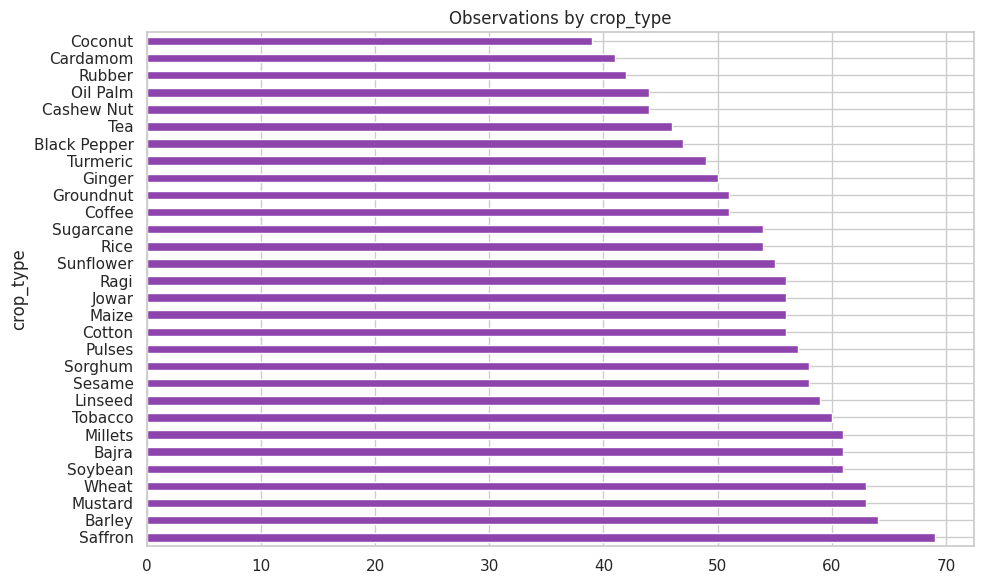

In [10]:

fig, ax = plt.subplots(figsize=(10, 6))
df1['crop_type'].value_counts().plot(kind='barh', ax=ax, color='#8e44ad')
ax.set_title('Observations by crop_type')
plt.tight_layout()
plt.savefig('reports/fig_crop_distribution.png', dpi=110)
plt.show()


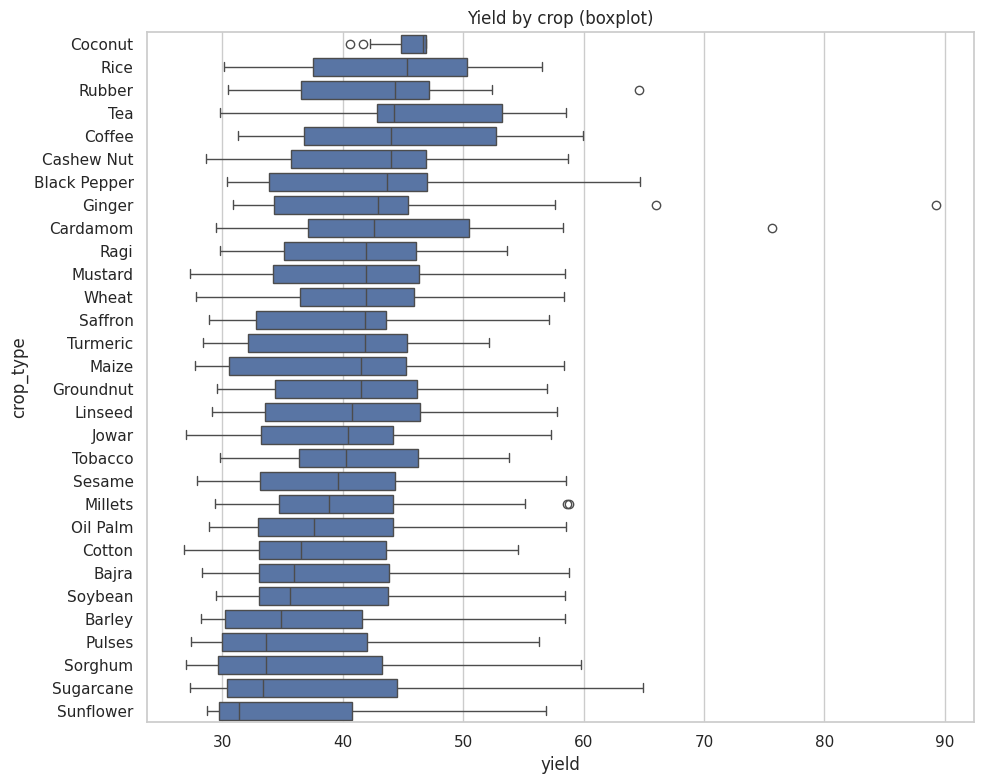

In [11]:

fig, ax = plt.subplots(figsize=(10, 8))
order = df1.groupby('crop_type')['yield'].median().sort_values(ascending=False).index
sns.boxplot(data=df1, y='crop_type', x='yield', order=order, ax=ax)
ax.set_title('Yield by crop (boxplot)')
plt.tight_layout()
plt.savefig('reports/fig_yield_by_crop.png', dpi=110)
plt.show()


## 10. Temporal Analysis

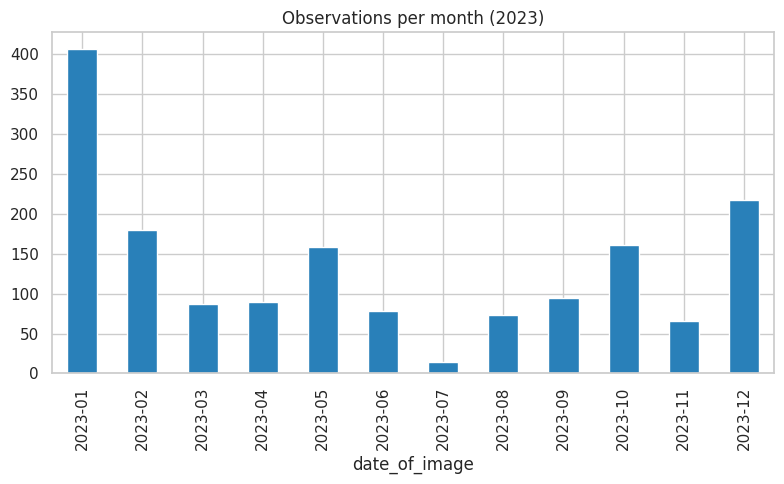

Date range: 2023-01-01 00:00:00 to 2023-12-27 00:00:00


In [12]:

d = parse_field_dates(df1['date_of_image'])
fig, ax = plt.subplots(figsize=FIGSIZE)
d.dt.to_period('M').value_counts().sort_index().plot(kind='bar', ax=ax, color='#2980b9')
ax.set_title('Observations per month (2023)')
plt.tight_layout()
plt.savefig('reports/fig_temporal_coverage.png', dpi=110)
plt.show()
print('Date range:', d.min(), 'to', d.max())


## 11. Geographic Analysis

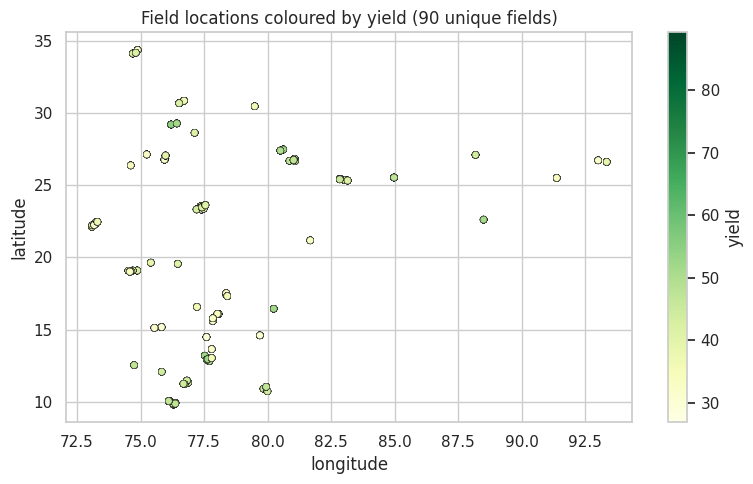

In [13]:

fig, ax = plt.subplots(figsize=FIGSIZE)
sc = ax.scatter(df1['longitude'], df1['latitude'], c=df1['yield'], cmap='YlGn', s=25, edgecolor='k', linewidth=0.3)
plt.colorbar(sc, label='yield')
ax.set_xlabel('longitude'); ax.set_ylabel('latitude')
ax.set_title('Field locations coloured by yield (90 unique fields)')
plt.tight_layout()
plt.savefig('reports/fig_geographic_distribution.png', dpi=110)
plt.show()


## 12. Satellite Feature Analysis

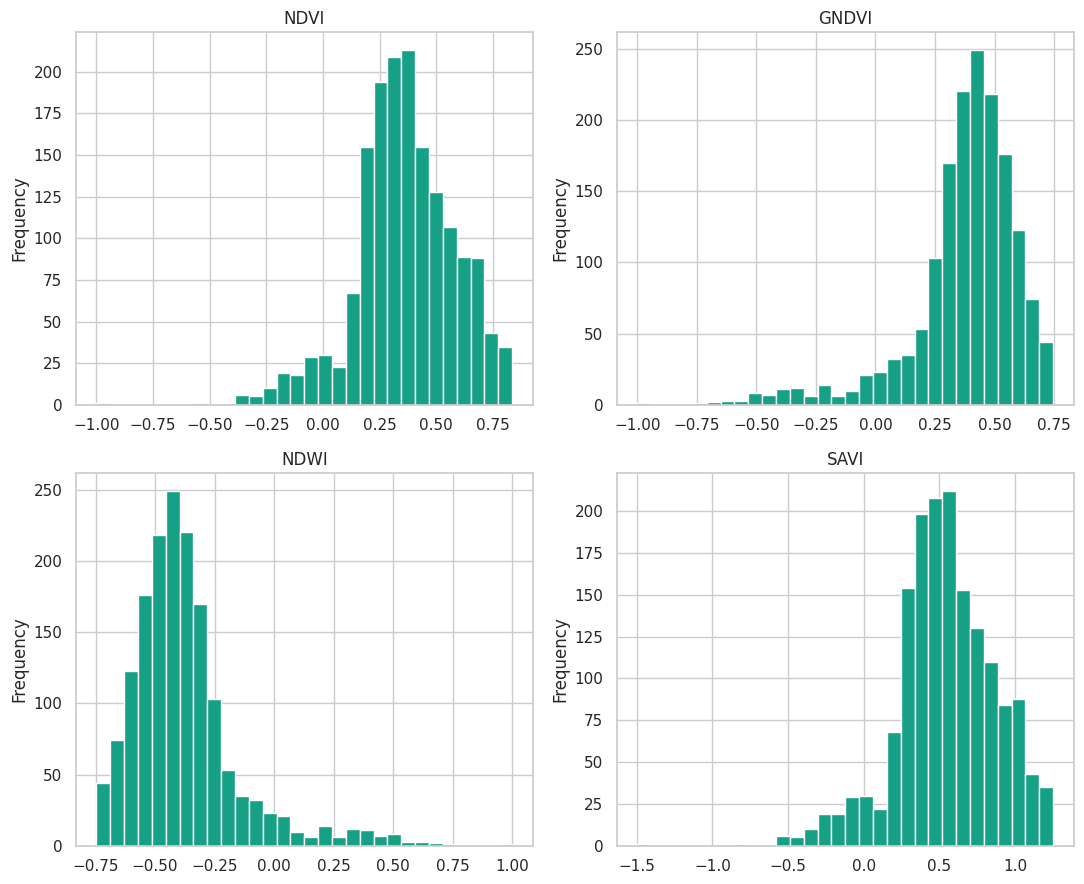

NDWI == -GNDVI exactly for all rows: True


In [14]:

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, col in zip(axes.ravel(), ['NDVI','GNDVI','NDWI','SAVI']):
    df1[col].plot(kind='hist', bins=30, ax=ax, color='#16a085')
    ax.set_title(col)
plt.tight_layout()
plt.savefig('reports/fig_satellite_features.png', dpi=110)
plt.show()
print('NDWI == -GNDVI exactly for all rows:', np.allclose(df1['NDWI'], -df1['GNDVI']))


## 13. Weather Analysis

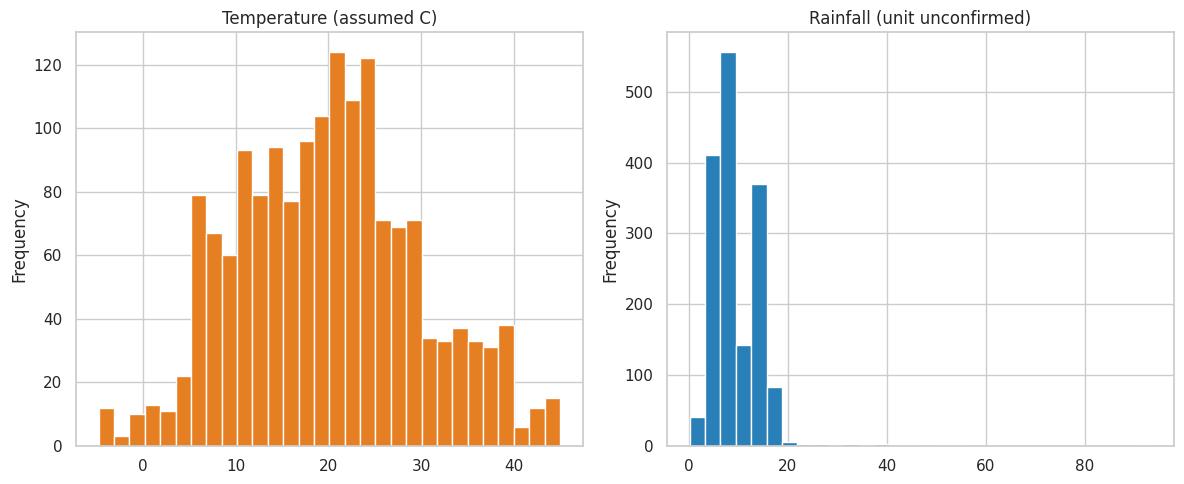

In [15]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
df1['temperature'].plot(kind='hist', bins=30, ax=axes[0], color='#e67e22')
axes[0].set_title('Temperature (assumed C)')
df1['rainfall'].plot(kind='hist', bins=30, ax=axes[1], color='#2980b9')
axes[1].set_title('Rainfall (unit unconfirmed)')
plt.tight_layout()
plt.savefig('reports/fig_weather_features.png', dpi=110)
plt.show()


## 14. Soil Analysis

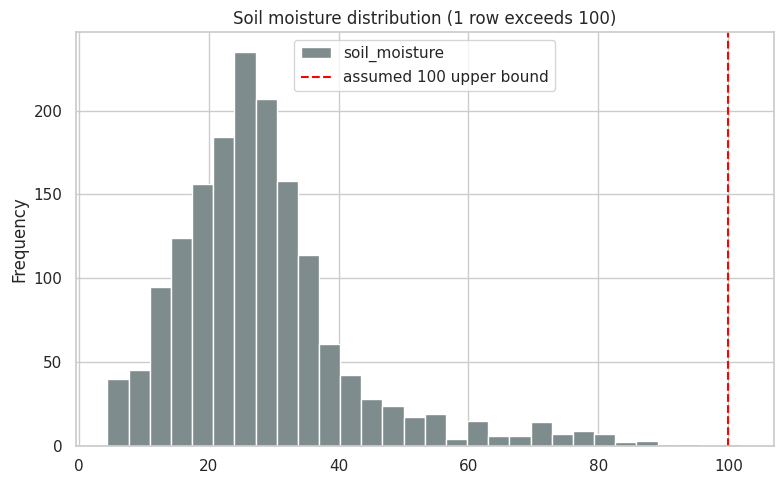

1 row(s) exceed 100


In [16]:

fig, ax = plt.subplots(figsize=FIGSIZE)
df1['soil_moisture'].plot(kind='hist', bins=30, ax=ax, color='#7f8c8d')
ax.axvline(100, color='red', linestyle='--', label='assumed 100 upper bound')
ax.legend()
ax.set_title('Soil moisture distribution (1 row exceeds 100)')
plt.tight_layout()
plt.savefig('reports/fig_soil_moisture.png', dpi=110)
plt.show()
print((df1['soil_moisture'] > 100).sum(), 'row(s) exceed 100')


## 15. Outlier Analysis (IQR method)

In [17]:

num_cols = ['NDVI','GNDVI','NDWI','SAVI','soil_moisture','temperature','rainfall','yield']
outlier_counts = {c: int(iqr_outlier_mask(df1[c]).sum()) for c in num_cols}
pd.Series(outlier_counts).sort_values(ascending=False)


GNDVI            104
NDWI             104
soil_moisture     89
NDVI              33
SAVI              33
rainfall          15
yield              3
temperature        0
dtype: int64

## 16. Correlation Analysis

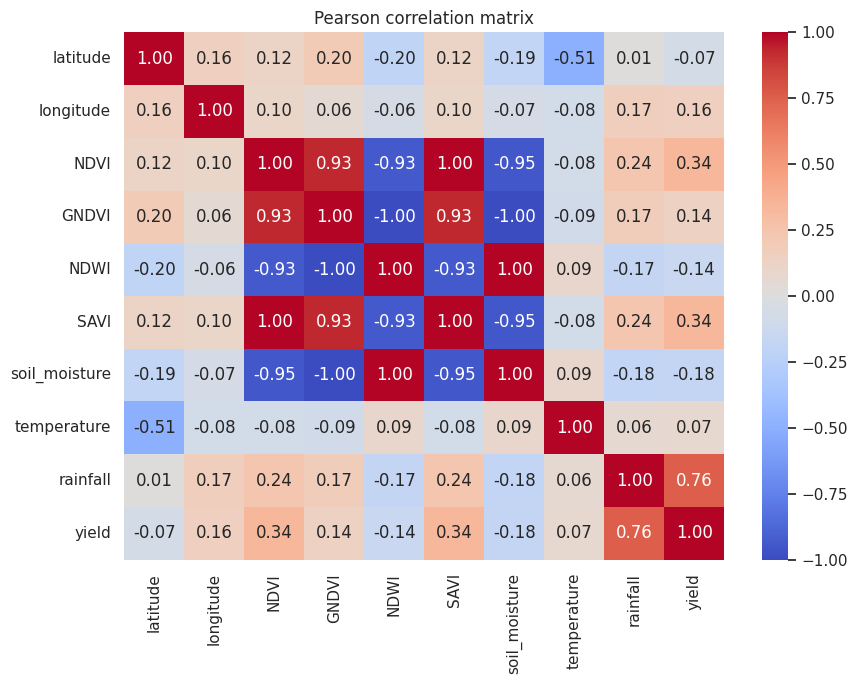

In [18]:

num = df1[['latitude','longitude','NDVI','GNDVI','NDWI','SAVI','soil_moisture','temperature','rainfall','yield']]
corr = num.corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Pearson correlation matrix')
plt.tight_layout()
plt.savefig('reports/fig_correlation_matrix.png', dpi=110)
plt.show()


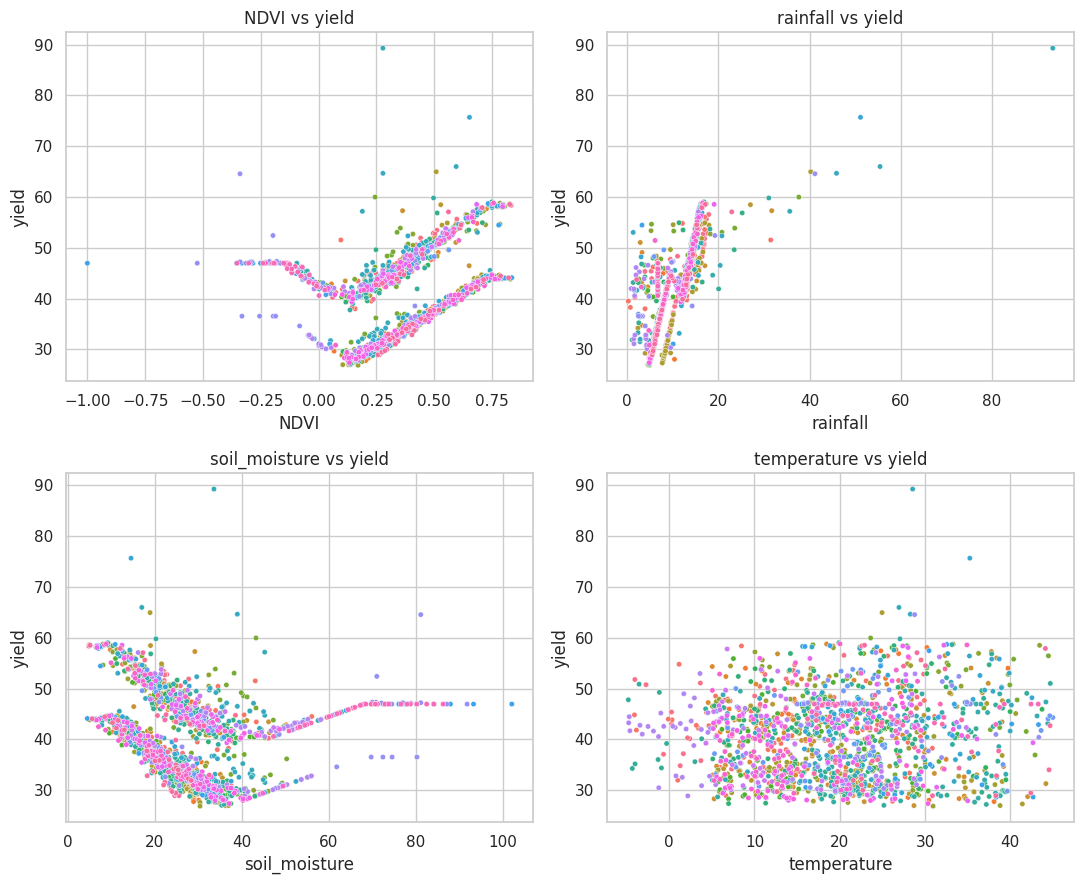

In [19]:

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, col in zip(axes.ravel(), ['NDVI','rainfall','soil_moisture','temperature']):
    sns.scatterplot(data=df1, x=col, y='yield', hue='crop_type', legend=False, s=15, ax=ax)
    ax.set_title(f'{col} vs yield')
plt.tight_layout()
plt.savefig('reports/fig_scatter_vs_yield.png', dpi=110)
plt.show()


## 17. Leakage Investigation
No `production`, `harvest_quantity`, or other target-derived columns exist in Dataset 1. The closest concern is `NDWI`, which is an exact deterministic negation of `GNDVI` in every row of this dataset (verified above) - a redundancy / multicollinearity note, not target leakage. Field-level leakage risk: each field_id contributes 12-25 rows, so a naive random row split would put the same field's other-date observations in both train and validation - Phase 2 must use a GroupShuffleSplit on `field_id` (see `reports/data_quality_report.md`).

Target-derived columns present: []


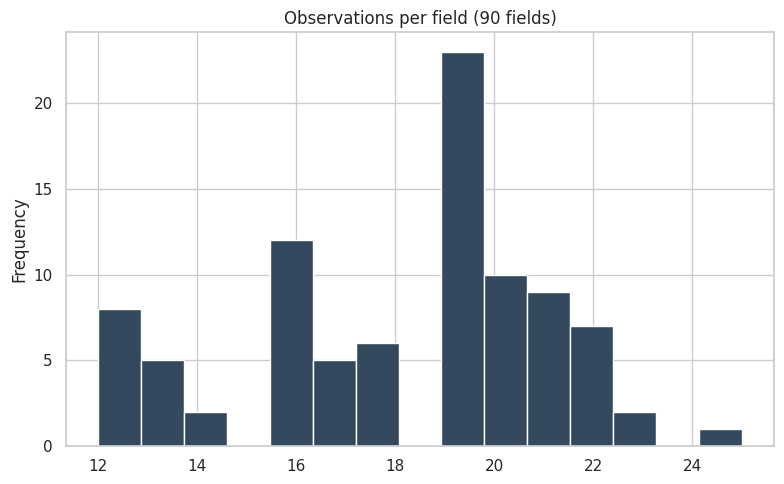

count    90.000000
mean     18.055556
std       3.095343
min      12.000000
25%      16.000000
50%      19.000000
75%      20.000000
max      25.000000
dtype: float64

In [20]:

suspicious = [c for c in df1.columns if c.lower() in ('production','harvest_quantity','yield_calculated','total_production','yield_per_area')]
print('Target-derived columns present:', suspicious)
obs_per_field = df1.groupby('field_id').size()
fig, ax = plt.subplots(figsize=FIGSIZE)
obs_per_field.plot(kind='hist', bins=15, ax=ax, color='#34495e')
ax.set_title('Observations per field (90 fields)')
plt.tight_layout()
plt.savefig('reports/fig_observations_per_field.png', dpi=110)
plt.show()
obs_per_field.describe()


## 18. Cleaning Decisions
See `src/data/clean_data.py` docstring and `reports/data_quality_report.md` section 20 for the full, itemized list of cleaning decisions applied (date parsing, crop_type normalization pass, soil_moisture flag, traceability columns). No values were fabricated or silently altered.

## 19. Final Dataset Validation

In [21]:

import subprocess
result = subprocess.run(['python3', 'src/data/validate_data.py'], capture_output=True, text=True)
print(result.stdout)


DATA VALIDATION
----------------------------------------
Schema: PASS
Target: PASS
Dates: PASS
    - min_date: 2023-01-01 00:00:00
    - max_date: 2023-12-27 00:00:00
    - span_days: 360
Coordinates: PASS
Missingness: PASS
Duplicates: PASS
Categories: PASS
Leakage: PASS
Units: WARNING
    - soil_moisture_over_100: 1
    - target_unit_unconfirmed: True
----------------------------------------
Overall: PASS WITH WARNINGS

Validation details written to reports/validation_results.csv



## 20. Save Processed Dataset

In [22]:

import subprocess
for script in ['src/data/clean_data.py', 'src/data/preprocess.py']:
    r = subprocess.run(['python3', script], capture_output=True, text=True)
    print(f'--- {script} ---')
    print(r.stdout[-1500:])
final = pd.read_csv('data/processed/crop_yield_model_data.csv')
print('Final model-ready dataset:', final.shape)
final.head()


--- src/data/clean_data.py ---
Loading raw data ...
Raw shape: (1625, 13)

Cleaning ...
crop_type: no normalization needed (already clean in raw data)
date_of_image: parsed as datetime, 0 parse failures
Missing value check: 0 missing cells across all columns (no imputation needed)
Duplicate check: 0 exact duplicate rows, 0 field_id+date_of_image duplicates
soil_moisture: flagged 1 row(s) exceeding 100 (unit/bound unconfirmed); value retained unaltered, not deleted

Cleaned shape: (1625, 16)

Wrote cleaned intermediate dataset to /sessions/rcw-013q2fmapnl1ay8vbvc6c25a/mnt/TechNexa/data/interim/dataset1_cleaned.csv



--- src/data/preprocess.py ---
essed/crop_yield_model_data.csv
Final shape: 1625 rows x 36 columns
Feature columns (30): ['latitude', 'longitude', 'NDVI', 'GNDVI', 'NDWI', 'SAVI', 'soil_moisture', 'temperature', 'rainfall', 'crop_type', 'year', 'month', 'day_of_year', 'month_sin', 'month_cos', 'doy_sin', 'doy_cos', 'field_obs_number', 'NDVI_field_expanding_mean', 'GNDVI_field_expanding_mean', 'SAVI_field_expanding_mean', 'soil_moisture_field_expanding_mean', 'rainfall_field_expanding_mean', 'temperature_field_expanding_mean', 'NDVI_field_expanding_std', 'GNDVI_field_expanding_std', 'SAVI_field_expanding_std', 'soil_moisture_field_expanding_std', 'rainfall_field_expanding_std', 'temperature_field_expanding_std']
Metadata columns (excluded from modeling): ['field_id', 'date_of_image', 'source_dataset', 'raw_row_index', 'soil_moisture_flag']
Target: yield

Note: the following engineered features contain NaN for each field's FIRST observation (no prior history exists yet) - by design, not 

,field_id,date_of_image,source_dataset,raw_row_index,soil_moisture_flag,latitude,longitude,NDVI,GNDVI,NDWI,SAVI,soil_moisture,temperature,rainfall,crop_type,year,month,day_of_year,month_sin,month_cos,doy_sin,doy_cos,field_obs_number,NDVI_field_expanding_mean,GNDVI_field_expanding_mean,SAVI_field_expanding_mean,soil_moisture_field_expanding_mean,rainfall_field_expanding_mean,temperature_field_expanding_mean,NDVI_field_expanding_std,GNDVI_field_expanding_std,SAVI_field_expanding_std,soil_moisture_field_expanding_std,rainfall_field_expanding_std,temperature_field_expanding_std,yield
0,Field_1,2023-01-01,dataset1_field_satellite,0,ok,22.625231,88.497925,0.060190,0.084801,-0.084801,0.090280,46.119353,9.884229,1.662354,Rice,2023,1,1,0.5,0.866025,0.017213,0.999852,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.218031
1,Field_1,2023-01-04,dataset1_field_satellite,6,ok,22.625231,88.497925,0.511423,0.467238,-0.467238,0.767016,21.982080,14.597473,17.527629,Rice,2023,1,4,0.5,0.866025,0.068802,0.997630,2,0.060190,0.084801,0.090280,46.119353,1.662354,9.884229,NaN,NaN,NaN,NaN,NaN,NaN,53.446685
2,Field_1,2023-01-05,dataset1_field_satellite,8,ok,22.625231,88.497925,0.499145,0.455279,-0.455279,0.748619,22.718146,11.234554,16.861559,Rice,2023,1,5,0.5,0.866025,0.085965,0.996298,3,0.285806,0.276019,0.428648,34.050716,9.594992,12.240851,0.319070,0.270424,0.478525,17.067630,11.218444,3.332767,52.789425
3,Field_1,2023-01-16,dataset1_field_satellite,1,ok,22.625231,88.497925,0.213957,0.222009,-0.222009,0.320896,37.542525,13.967073,8.446302,Rice,2023,1,16,0.5,0.866025,0.271958,0.962309,4,0.356919,0.335772,0.535305,30.273193,12.017181,11.905419,0.257049,0.217430,0.385513,13.728111,8.973725,2.427182,30.870338
4,Field_1,2023-01-31,dataset1_field_satellite,2,ok,22.625231,88.497925,0.403306,0.431204,-0.431204,0.604837,24.926279,13.590147,3.862833,Rice,2023,1,31,0.5,0.866025,0.508671,0.860961,5,0.321179,0.307331,0.481703,32.090526,11.124461,12.420832,0.221718,0.186421,0.332525,11.783526,7.541416,2.233848,45.330050
